In [7]:
# Script for NB-NC contact duration ROC analysis shown in Figure S2

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
df = pd.read_csv('CombinedMatrixPreWindowFirstSignFrameFINAL0925.csv')
df = df.dropna(subset=['area', 'contact_length', 'contact_duration', 'signalling'])

df = df[df['contact_duration'] >= 0]

duration_signal = df.loc[df['signalling'] == 1, 'contact_duration']
duration_no_signal = df.loc[df['signalling'] == 0, 'contact_duration']

In [9]:
# Combine into one array
contacts = np.array(list(duration_signal) + list(duration_no_signal))
labels = np.array([1] * len(duration_signal) + [0] * len(duration_no_signal))

# Compute ROC
fpr, tpr, thresholds = roc_curve(labels, contacts)
roc_auc = auc(fpr, tpr)

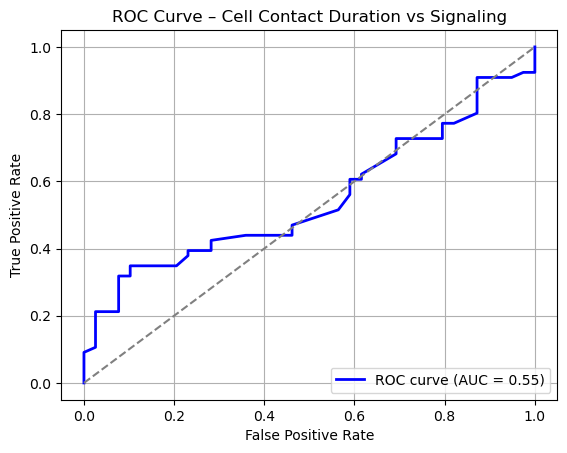

In [10]:
# Plot
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Cell Contact Duration vs Signaling')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('ROC Contact Duration vs Signalling.pdf')
plt.show()

In [7]:
# Youden's J for all thresholds
youden_j = tpr - fpr

# Index of the max J
j_idx = np.argmax(youden_j)

# Optimal threshold
optimal_threshold = thresholds[j_idx]

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"TPR: {tpr[j_idx]:.2f}, FPR: {fpr[j_idx]:.2f}, Youden's J: {youden_j[j_idx]:.2f}")

Optimal threshold: 10.00
TPR: 0.57, FPR: 0.44, Youden's J: 0.12
